# OPERA DISP-S1, part 1: land subsidence in the southern Central Valley

Corcoran, California sits in the fastest-subsiding part of the San Joaquin Valley.
Groundwater pumped for irrigation compacts the aquifer's clay layers, and the ground
surface has dropped by several meters since the 1920s. The rate is not steady: it
accelerates in drought years and nearly stops in wet ones.

We will measure that with **OPERA DISP-S1** (Level-3 Surface Displacement from Sentinel-1),
produced by JPL and distributed by the ASF DAAC.

What you need to know about the product:

- **Frame-based.** A frame is a fixed footprint on the ground that does not move between
  acquisitions, so the stack lines up pixel-for-pixel with no coregistration on your part.
- **Geocoded** onto a 30 m UTM grid (different frames can be in different UTM zones).
- **Line-of-sight displacement in meters**, positive meaning *towards* the satellite.
- **Chunked NetCDF4/HDF5**, so an S3 client can read a small spatial window without
  transferring the whole file.
- **The reference date moves forward in time.** It must be handled before the measurements
  can be interpreted as one continuous time series.

---
By the end you will have a rebased displacement stack over Corcoran, ready for MintPy in part 2.

## Adjusting the OpenScienceLab kernel


In [8]:
%pip install --upgrade dolphin "zarr>=3" rioxarray \
  "opera-utils[asf,disp,geopandas,tropo] @ git+https://github.com/scottstanie/opera-utils.git@develop-scott"

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/scottstanie/opera-utils.git (to revision develop-scott) to /tmp/pip-install-lomlxigm/opera-utils_ffeeea5542874c40998d357cff064a67
  Running command git clone --filter=blob:none --quiet https://github.com/scottstanie/opera-utils.git /tmp/pip-install-lomlxigm/opera-utils_ffeeea5542874c40998d357cff064a67
  Running command git checkout -b develop-scott --track origin/develop-scott
  Switched to a new branch 'develop-scott'
  branch 'develop-scott' set up to track 'origin/develop-scott'.
  Resolved https://github.com/scottstanie/opera-utils.git to commit d19306a3e2499a14590c0cd2b031b497cb4382b8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


You may need to restart the kernel, and then this will work!

In [2]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import opera_utils
from opera_utils import Bbox, disp

%matplotlib inline

## Finding a DISP-S1 frame to cover the Central Valley

DISP-S1 is indexed by frame ID, so the first job is turning a place into a frame.

You can click around on the [ASF displacement portal](https://displacement.asf.alaska.edu/), check the "Frame ID" that comes up for the ascending (or descending) pass.
However, it can be easier to ask `opera-utils` directly.

In [7]:
# Corcoran, CA and the subsidence bowl around it.
AOI_BBOX = Bbox(left=-119.85, bottom=35.90, right=-119.05, top=36.45)

frames = opera_utils.get_intersecting_frames(AOI_BBOX)
for feature in frames["features"]:
    print(f"frame {feature['id']:>6s}  {feature['properties']['orbit_pass']}")

frame  16942  ASCENDING
frame  36541  ASCENDING
frame  36542  ASCENDING
frame  38502  DESCENDING


Several frames overlap the AOI, because ascending and descending tracks both see this area.
We will use the descending frame **38502**.

A frame only covers part of the valley, so if your own area of interest straddles two frames you should process each one separately and mosaic afterwards. 

You can also try to stitch corresponding dates together before fitting a velocity, but note that not all adjacent frames have the same dates.
More details of how the S1 bursts were chosen in in the Burst DB repo: https://github.com/opera-adt/burst_db/tree/main/scripts/historical_bursts

In [8]:
FRAME_ID = 38502

products = disp.search(frame_id=FRAME_ID)
print(f"{len(products)} products available")
print(
    f"spanning {products[0].secondary_datetime.date()} to {products[-1].secondary_datetime.date()}"
)
print(f"full frame is {products[0].shape} pixels (~450 MB per granule)")

359 products available
spanning 2016-08-17 to 2025-10-17
full frame is (7197, 9806) pixels (~450 MB per granule)


## Referencing  moving reference date

Each DISP-S1 granule holds the displacement between a reference date and a secondary date. If the reference date were fixed for all time, every granule would already be a cumulative displacement map and there would be nothing else to do.

However, due to tradeoffs/limitations for the production data system, the granules were produced with a moving reference frame. That is, each batch that OPERA processes is run in **ministacks** of up to ~15 acquisitions: within one ministack the reference is held constant, and then it jumps forward to start the next one.
Plotting reference date against secondary date shows the structure immediately.

/tmp/ipykernel_360/3695666720.py:2: UserWarning: no explicit representation of timezones available for np.datetime64
  ref_dates = np.array(stack.reference_dates, dtype="datetime64[s]")
/tmp/ipykernel_360/3695666720.py:3: UserWarning: no explicit representation of timezones available for np.datetime64
  sec_dates = np.array(stack.secondary_dates, dtype="datetime64[s]")


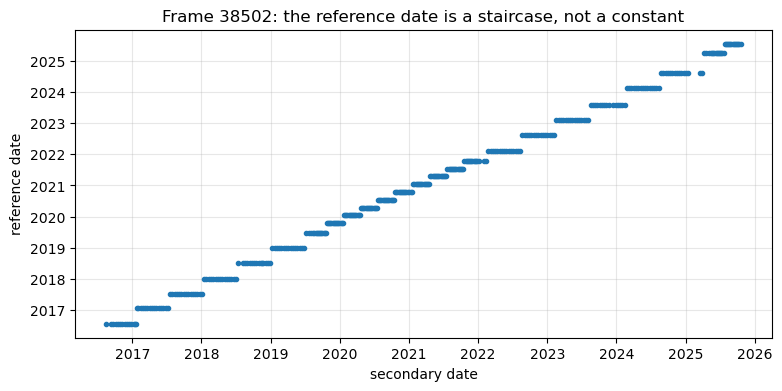

In [9]:
stack = disp.DispProductStack(products)
ref_dates = np.array(stack.reference_dates, dtype="datetime64[s]")
sec_dates = np.array(stack.secondary_dates, dtype="datetime64[s]")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sec_dates, ref_dates, "o", ms=3)
ax.set_xlabel("secondary date")
ax.set_ylabel("reference date")
ax.set_title(f"Frame {FRAME_ID}: the reference date is a staircase, not a constant")
ax.grid(alpha=0.3)

Every horizontal line is one "ministack" (in the nomenclature of `dolphin`). Due to how the OPERA data system was set up, the reference jumps to the last date of the previous ministack.

If you naively stack the `displacement` layers and plot one pixel, your plot looks like a sawtooth, where the series resets towards zero at every ministack boundary. To recover a continuous time series you have to add the accumulated displacement of all preceding ministacks.

A general way to solve this would be to do a "network inversion" like MintPY has; however, we know this is a simple daisy chain, so we can do a simple cumulative sum.

A practical consequence: you can request any date window you like. There is no need to start or stop on a ministack boundary, because rebasing handles a partial ministack the same way it handles a whole one.

While this is a minor annoyance, this does offer the benefit that if a time period (say the period of 2014-2019) led to especially high decorrelation for a region, you can still download and process the later periods that are less noisy and not worry about all pixels being masked.

## Download a subset

`opera-utils disp-s1-download` searches, downloads and crops in one step. The crop happens
before anything is written to disk, so you get ~46 MB per date instead of ~450 MB.

**On OpenScienceLab, always pass `--url-type S3`.** OSL runs in the same AWS region as the
ASF archive, so S3 reads only the bytes of your AOI. Over HTTPS the whole 450 MB granule is
pulled down first and then cropped, which is roughly 10x slower.

In [6]:
!mkdir -p subsets

We take 2020 through mid-2024: 192 granules across 14 ministacks, about 11 GB cropped. That
window brackets the 2020-2022 drought, when pumping accelerated the subsidence, and the
2023 atmospheric-river winter that partly reversed it.

In [9]:
%%bash
time opera-utils disp-s1-download \
    --frame-id 38502 \
    --bbox -119.85 35.90 -119.05 36.45 \
    --start-datetime 2020-01-01 \
    --end-datetime 2024-06-01 \
    --url-type S3 \
    --num-workers 8 \
    --output-dir subsets

Found 192 urls for Frame 38502
Subsetting to Rows: slice(3129, 5224, None), cols: slice(3323, 5671, None)
100%|██████████| 192/192 [30:20<00:00,  9.48s/it]

real	30m27.713s
user	72m31.208s
sys	1m18.920s


### Verify download completeness

Transient archive errors can leave an incomplete final ministack without causing a later
processing error. During testing, separate runs stopped on an Earthdata `403 Forbidden`
and an ASF `502 Bad Gateway`.

If the counts differ, run the download command again. Existing files are skipped.

In [10]:
expected = disp.search(
    frame_id=FRAME_ID,
    start_datetime=datetime(2020, 1, 1),
    end_datetime=datetime(2024, 6, 1),
)
downloaded = sorted(Path("subsets").glob("OPERA*.nc"))
print(f"on disk: {len(downloaded)}   expected: {len(expected)}")
assert len(downloaded) == len(expected), "Incomplete download - re-run the cell above"

on disk: 192   expected: 192


## Check on downloaded granules

First we can see what the downloaded granules as they came, with no rebasing, and look at one pixel inside the subsidence bowl.

In [11]:
files = sorted(Path("subsets").glob("OPERA*.nc"))
print(f"{len(files)} files")

ds_raw = xr.open_mfdataset(
    files, engine="h5netcdf", combine="nested", concat_dim="time", data_vars="all"
)

192 files


`DispProductStack` reads the geometry straight out of the filenames, and it is just as happy
with cropped files as with full frames - it reports the *subset's* grid, so its row/col are
the ones you want for indexing what you actually downloaded.

In [12]:
subset = disp.DispProductStack.from_file_list(files)
print(f"EPSG:{subset.epsg}, shape {subset.shape}")

# A pixel in the middle of the Corcoran subsidence bowl.
LON, LAT = -119.56, 36.15
row, col = subset.lonlat_to_rowcol(LON, LAT)
print(f"lon/lat ({LON}, {LAT}) -> row {row}, col {col}")

EPSG:32611, shape (192, 2095, 2348)
lon/lat (-119.56, 36.15) -> row 1134, col 838


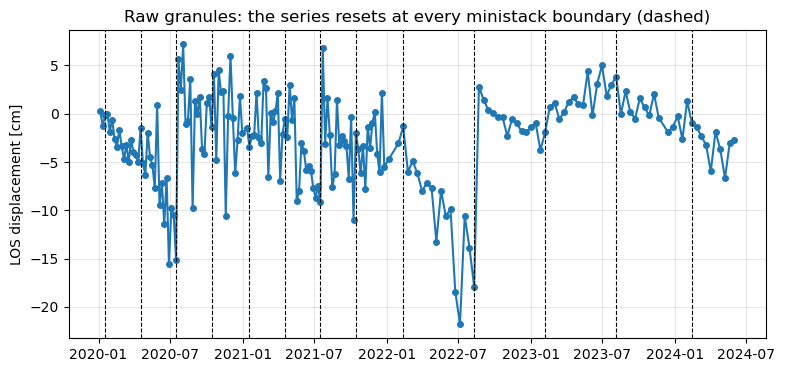

In [13]:
ts_raw = ds_raw.displacement.isel(y=row, x=col).compute()
ref_time = ds_raw.reference_time.compute()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ts_raw.time, ts_raw * 100, "o-", ms=4)
for boundary in np.unique(ref_time.values)[1:]:
    ax.axvline(boundary, color="k", ls="--", lw=0.8)
ax.set_ylabel("LOS displacement [cm]")
ax.set_title("Raw granules: the series resets at every ministack boundary (dashed)")
ax.grid(alpha=0.3)

## Rebase into one continuous time series

`opera-utils disp-s1-reformat` does the accumulation and writes a single stack file. It
also handles three related operations:

- **`--reference-method`** picks the *spatial* reference, the pixel (or set of pixels) that is defined to be motionless. `BORDER` uses the median of the edge pixels; `HIGH_COHERENCE` uses the median of everything above a coherence threshold; `POINT` takes a lat/lon you choose. Note this is independent of the *temporal* reference date.
- **corrections**: solid-earth tide is applied by default, ionospheric delay is not. Neither is necessary if your cropped AOI is small (where small is ~under 100km per side)
- **quality masking** while accumulating, via `--quality-datasets`.

`--quality-datasets` decides which pixels get masked *before* accumulating, and it defaults to `RECOMMENDED_MASK`. Masking happens per epoch, and a masked crossover can make a pixel invalid for every later date. On the 2020-2022 portion of this stack:

| reformat settings | valid pixels at the first epoch | at the last |
|---|---|---|
| `RECOMMENDED_MASK` (default) | 97.5% | **57.7%** |
| `--quality-datasets None` | 99.9% | **99.9%** |

Irrigated farmland often decorrelates between passes. In this example, applying the mask during rebasing removes about 40% of the scene by the final date, including the Corcoran pixel used below.

For this exercise we do not mask during rebasing. We retain the source observations and apply the recommended mask during analysis. This lets us experiment with different quality metric thresholds.

Choosing an AOI that reaches east to about -119.05 puts the Sierra foothills inside the box, which gives us a stable spatial reference point.

In [14]:
%%bash
time opera-utils disp-s1-reformat \
    --input-files subsets/OPERA*.nc \
    --output-name corcoran-stack.nc \
    --reference-method BORDER \
    --quality-datasets None \
    --drop-vars shp_counts estimated_phase_quality

Starting displacement stack rebasing
spatially referencing with border
Starting displacement stack rebasing


Wrote minimal dataset: <xarray.Dataset> Size: 20MB
Dimensions:                 (time: 192, y: 2095, x: 2348)
Coordinates:
  * y                       (y) float64 17kB 4.038e+06 4.038e+06 ... 3.975e+06
  * x                       (x) float64 19kB 2.446e+05 2.446e+05 ... 3.15e+05
  * time                    (time) datetime64[ns] 2kB 2020-01-05T14:00:00.815...
Data variables:
    spatial_ref             (time) int64 2kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    reference_time          (time) datetime64[ns] 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    water_mask              (y, x) float32 20MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    perpendicular_baseline  (time) float32 768B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.8
    contact:             opera-sds-ops@jpl.nasa.gov
    institution:         NASA JPL
    mission_name:        OPERA
    reference_document:  JPL D-108765
    title:               OPERA_L3_DISP-S1 Product
 in 30


real	21m17.367s
user	20m33.034s
sys	0m36.191s


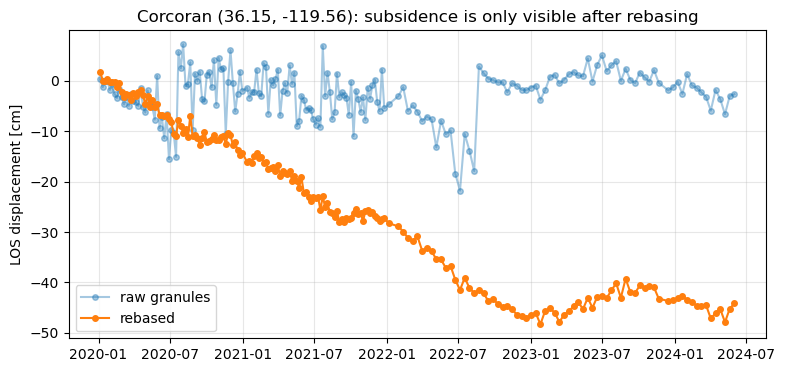

In [14]:
ds = xr.open_dataset("corcoran-stack.nc")
ts = ds.displacement.isel(y=row, x=col)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ts_raw.time, ts_raw * 100, "o-", ms=4, alpha=0.4, label="raw granules")
ax.plot(ts.time, ts * 100, "o-", ms=4, label="rebased")
ax.set_ylabel("LOS displacement [cm]")
ax.set_title(f"Corcoran ({LAT}, {LON}): subsidence is only visible after rebasing")
ax.legend()
ax.grid(alpha=0.3)

### Comparing drought years to wet years

Notice the "bounce" in the time series during 2023!

California had multiple atmospheric rivers that winter, and we can see the groundwater recharge in the time series.

In [16]:
years = (ts.time - ts.time[0]) / np.timedelta64(365, "D")
finite = np.isfinite(ts)

for label, lo, hi in [
    ("2020-01 to 2022-09  (drought)", "2020-01-01", "2022-09-30"),
    ("2022-10 to 2024-05  (after the atmospheric rivers)", "2022-10-01", "2024-06-01"),
]:
    window = (ts.time >= np.datetime64(lo)) & (ts.time < np.datetime64(hi)) & finite
    rate = np.polyfit(years[window], ts[window] * 100, 1)[0]
    print(f"{label}: {rate:6.1f} cm/yr")

2020-01 to 2022-09  (drought):  -15.5 cm/yr
2022-10 to 2024-05  (after the atmospheric rivers):    1.1 cm/yr


The fitted LOS rate is -15 cm/yr during the first interval and +1.1 cm/yr during the second. 
At this pixel, the strong downward trend stops and becomes a small positive trend after late 2022. That change is consistent with reduced pumping and recharge after the wet 2022-2023 winter. 

## Finding reliable pixels

DISP-S1 includes several quality layers. We use two here:

- `temporal_coherence` (0-1): how well all the interferograms agree with the phase-linking solution. This is *not* MintPy's `temporalCoherence`.
- `phase_similarity` (-1 to 1): median cosine similarity between a pixel and its neighbours. Negative means the pixel disagrees with everything around it.

`recommended_mask` combines those with the water mask and connected-component labels. It is useful for display and screening even though we chose not to apply it during rebasing. 
Users may choose to ignore it to see all noisy pixels and choose their own mask based on longer-term statistics

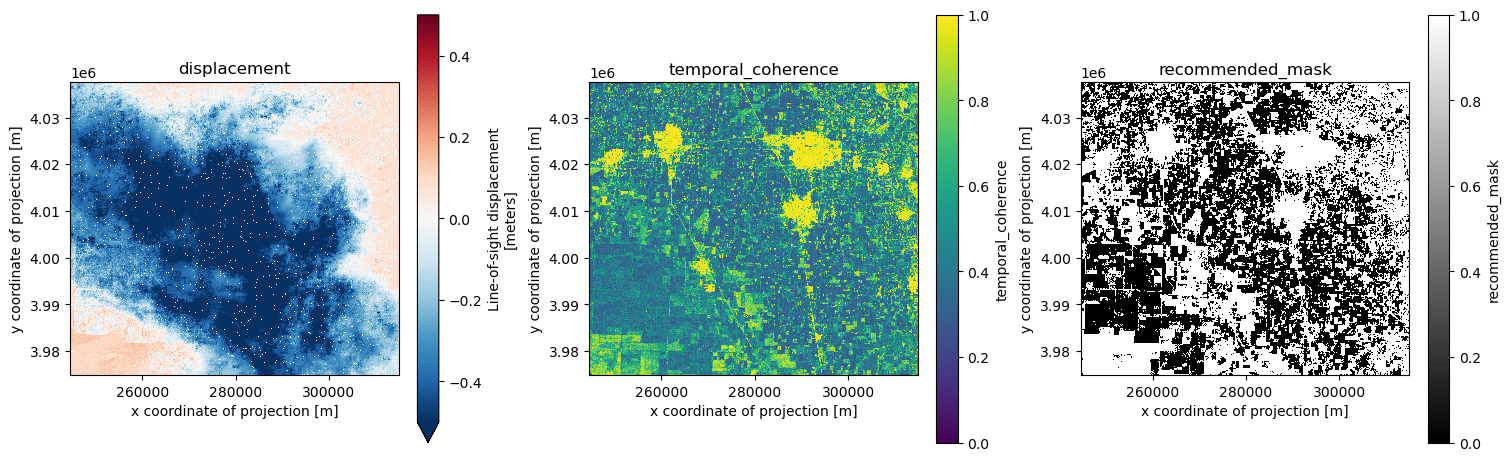

In [15]:
last = ds.isel(time=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, name, kw in [
    (axes[0], "displacement", dict(cmap="RdBu_r", vmin=-0.5, vmax=0.5)),
    (axes[1], "temporal_coherence", dict(cmap="viridis", vmin=0, vmax=1)),
    (axes[2], "recommended_mask", dict(cmap="gray", vmin=0, vmax=1)),
]:
    last[name].plot.imshow(ax=ax, **kw)
    ax.set_aspect("equal")
    ax.set_title(name)

## Average velocity

Since we have a single-refernce time series, we can plot an average velocity using `xarray.polyfit`.

In part 2 we use `MintPy` do this instead.

Text(0.5, 1.0, 'Frame 38502 LOS velocity')

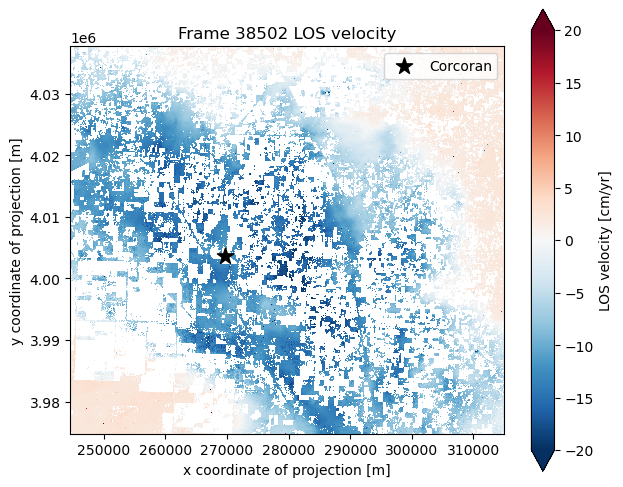

In [16]:
masked = ds.displacement.where(last.recommended_mask == 1)
years = (ds.time - ds.time[0]) / np.timedelta64(365, "D")

fit = masked.assign_coords(time=years).polyfit("time", deg=1)
velocity_cm_yr = fit.polyfit_coefficients.sel(degree=1) * 100

fig, ax = plt.subplots(figsize=(7, 6))
velocity_cm_yr.plot.imshow(
    ax=ax,
    cmap="RdBu_r",
    vmin=-20,
    vmax=20,
    cbar_kwargs={"label": "LOS velocity [cm/yr]"},
)
ax.scatter(ds.x[col], ds.y[row], marker="*", s=150, c="k", label="Corcoran")
ax.set_aspect("equal")
ax.legend()
ax.set_title(f"Frame {FRAME_ID} LOS velocity")

**Next:** part 2 converts this stack to MintPy format and compares it against the ASF displacement portal.